Cell 1: Setup & Install Dependencies

In [1]:
import sys
import subprocess

# Auto-install required packages
packages = ['optuna', 'catboost']
for package in packages:
    try:
        __import__(package)
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])
        print(f"✅ {package} installed")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("\n✅ Setup complete!")

f:\AI Project\airbnb-price-predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ optuna already installed
📦 Installing catboost...
✅ catboost installed

✅ Setup complete!


Cell 2: Load Processed Data

In [2]:
# Load processed data from Phase 3
X_train = pd.read_csv("../data/processed/X_train.csv")
X_val = pd.read_csv("../data/processed/X_val.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_val = pd.read_csv("../data/processed/y_val.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"📊 Data Loaded:")
print(f"   X_train: {X_train.shape}")
print(f"   X_val:   {X_val.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   Features: {X_train.shape[1]}")
print(f"   Target range (log): {y_train.min():.2f} - {y_train.max():.2f}")

📊 Data Loaded:
   X_train: (8345, 109)
   X_val:   (1789, 109)
   X_test:  (1789, 109)
   Features: 109
   Target range (log): 2.40 - 7.72


Cell 3: Import ML Libraries

In [3]:
# Basic models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Advanced models
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, StackingRegressor

# Evaluation
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Hyperparameter tuning
import optuna

# Utilities
import joblib
import os
import time

print("✅ All ML libraries imported!")

✅ All ML libraries imported!


Cell 4: Evaluation Function

In [4]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, name="Model", verbose=True):
    """Train and evaluate a model, return metrics dictionary"""
    start = time.time()
    
    # Train
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Predict log scale
    y_train_pred_log = model.predict(X_train)
    y_val_pred_log = model.predict(X_val)
    y_test_pred_log = model.predict(X_test)
    
    # Convert to original price ($)
    y_train_pred = np.expm1(y_train_pred_log)
    y_val_pred = np.expm1(y_val_pred_log)
    y_test_pred = np.expm1(y_test_pred_log)
    
    y_train_orig = np.expm1(y_train)
    y_val_orig = np.expm1(y_val)
    y_test_orig = np.expm1(y_test)
    
    metrics = {
        'name': name,
        'model': model,
        'train_r2': r2_score(y_train_orig, y_train_pred),
        'val_r2': r2_score(y_val_orig, y_val_pred),
        'test_r2': r2_score(y_test_orig, y_test_pred),
        'train_rmse': np.sqrt(mean_squared_error(y_train_orig, y_train_pred)),
        'val_rmse': np.sqrt(mean_squared_error(y_val_orig, y_val_pred)),
        'test_rmse': np.sqrt(mean_squared_error(y_test_orig, y_test_pred)),
        'train_mae': mean_absolute_error(y_train_orig, y_train_pred),
        'val_mae': mean_absolute_error(y_val_orig, y_val_pred),
        'test_mae': mean_absolute_error(y_test_orig, y_test_pred),
        'train_time': train_time
    }
    
    if verbose:
        print(f"   {name}: Test R²={metrics['test_r2']:.4f}, RMSE=${metrics['test_rmse']:.2f}, Time={train_time:.1f}s")
    
    return metrics

# Store all results
all_results = []

Cell 5: BASELINE MODELS (Phase 4 Original Results)

In [5]:
print("="*60)
print("📊 TRAINING BASELINE MODELS")
print("="*60)

# 1. Mean Predictor
class MeanPredictor:
    def fit(self, X, y):
        self.mean = np.mean(y)
    def predict(self, X):
        return np.full(X.shape[0], self.mean)

mean_model = MeanPredictor()
result_mean = evaluate_model(mean_model, X_train, y_train, X_val, y_val, X_test, y_test, "Mean Baseline")
all_results.append(result_mean)

# 2. Linear Regression
lr = LinearRegression()
result_lr = evaluate_model(lr, X_train, y_train, X_val, y_val, X_test, y_test, "Linear Regression")
all_results.append(result_lr)

# 3. Ridge Regression
ridge = Ridge(alpha=1.0)
result_ridge = evaluate_model(ridge, X_train, y_train, X_val, y_val, X_test, y_test, "Ridge Regression")
all_results.append(result_ridge)

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=20, min_samples_split=10, 
                           min_samples_leaf=5, random_state=42, n_jobs=-1)
result_rf = evaluate_model(rf, X_train, y_train, X_val, y_val, X_test, y_test, "Random Forest")
all_results.append(result_rf)

# 5. XGBoost (Default)
xgb_default = xgb.XGBRegressor(n_estimators=500, max_depth=7, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=0)
result_xgb_default = evaluate_model(xgb_default, X_train, y_train, X_val, y_val, X_test, y_test, "XGBoost Default")
all_results.append(result_xgb_default)

# 6. LightGBM (Default)
lgb_default = lgb.LGBMRegressor(n_estimators=500, max_depth=10, learning_rate=0.05,
                                subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1)
result_lgb_default = evaluate_model(lgb_default, X_train, y_train, X_val, y_val, X_test, y_test, "LightGBM Default")
all_results.append(result_lgb_default)

# 7. Gradient Boosting
gbm = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, 
                                subsample=0.8, random_state=42)
result_gbm = evaluate_model(gbm, X_train, y_train, X_val, y_val, X_test, y_test, "Gradient Boosting")
all_results.append(result_gbm)

print(f"\n✅ {len(all_results)} baseline models trained!")

📊 TRAINING BASELINE MODELS
   Mean Baseline: Test R²=-0.0734, RMSE=$180.26, Time=0.0s
   Linear Regression: Test R²=0.5726, RMSE=$113.75, Time=0.1s
   Ridge Regression: Test R²=0.5726, RMSE=$113.75, Time=0.1s
   Random Forest: Test R²=0.6826, RMSE=$98.03, Time=3.7s
   XGBoost Default: Test R²=0.7385, RMSE=$88.97, Time=2.2s
   LightGBM Default: Test R²=0.7244, RMSE=$91.34, Time=0.7s
   Gradient Boosting: Test R²=0.7190, RMSE=$92.23, Time=16.3s

✅ 7 baseline models trained!


Cell 6: Baseline Comparison

In [6]:
# Sort by Test R²
all_results.sort(key=lambda x: x['test_r2'], reverse=True)

print("="*75)
print("📊 BASELINE MODEL COMPARISON")
print("="*75)
print(f"{'Model':<25} {'Test R²':>8} {'Test RMSE':>10} {'Test MAE':>10} {'Time':>8}")
print("-"*75)

best_baseline = all_results[0]
for r in all_results:
    marker = "🏆" if r['name'] == best_baseline['name'] else "  "
    print(f"{marker} {r['name']:<23} {r['test_r2']:>8.4f} ${r['test_rmse']:>8.2f} ${r['test_mae']:>8.2f} {r['train_time']:>7.1f}s")

print("="*75)
print(f"🏆 Best Baseline: {best_baseline['name']} (R²={best_baseline['test_r2']:.4f})")
print("="*75)

baseline_best_r2 = best_baseline['test_r2']

📊 BASELINE MODEL COMPARISON
Model                      Test R²  Test RMSE   Test MAE     Time
---------------------------------------------------------------------------
🏆 XGBoost Default           0.7385 $   88.97 $   43.34     2.2s
   LightGBM Default          0.7244 $   91.34 $   45.00     0.7s
   Gradient Boosting         0.7190 $   92.23 $   45.84    16.3s
   Random Forest             0.6826 $   98.03 $   48.37     3.7s
   Ridge Regression          0.5726 $  113.75 $   60.59     0.1s
   Linear Regression         0.5726 $  113.75 $   60.62     0.1s
   Mean Baseline            -0.0734 $  180.26 $  106.11     0.0s
🏆 Best Baseline: XGBoost Default (R²=0.7385)


Cell 7: OPTUNA TUNING - XGBoost

In [7]:
print("\n" + "="*60)
print("🔄 OPTUNA HYPERPARAMETER TUNING - XGBoost")
print("="*60)

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 3),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }
    
    model = xgb.XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction='maximize', study_name='xgb_tuning')
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ XGBoost Best CV R²: {study_xgb.best_value:.4f}")
print(f"📋 Best Params: {study_xgb.best_params}")

# Train tuned model
best_xgb = xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1, verbosity=0)
result_xgb_tuned = evaluate_model(best_xgb, X_train, y_train, X_val, y_val, X_test, y_test, "XGBoost Tuned")
all_results.append(result_xgb_tuned)

[I 2026-04-29 18:35:38,828] A new study created in memory with name: xgb_tuning



🔄 OPTUNA HYPERPARAMETER TUNING - XGBoost


Best trial: 0. Best value: 0.795716:   3%|▎         | 1/30 [00:10<04:51, 10.06s/it]

[I 2026-04-29 18:35:48,904] Trial 0 finished with value: 0.7957161812938147 and parameters: {'n_estimators': 650, 'max_depth': 8, 'learning_rate': 0.02433972333105026, 'subsample': 0.6907736969397154, 'colsample_bytree': 0.7535643974304485, 'min_child_weight': 2, 'gamma': 2.1067139041212117, 'reg_alpha': 0.3463451225465769, 'reg_lambda': 2.6210557907064174}. Best is trial 0 with value: 0.7957161812938147.


Best trial: 0. Best value: 0.795716:   7%|▋         | 2/30 [00:16<03:37,  7.75s/it]

...

[I 2026-04-29 18:37:21,112] Trial 27 finished with value: 0.8035178509399288 and parameters: {'n_estimators': 700, 'max_depth': 9, 'learning_rate': 0.06367332707480458, 'subsample': 0.7254583340619642, 'colsample_bytree': 0.6024209037436163, 'min_child_weight': 8, 'gamma': 0.6896343470116517, 'reg_alpha': 4.506289349346114, 'reg_lambda': 2.6773760458314837}. Best is trial 24 with value: 0.8253143970786715.


Best trial: 24. Best value: 0.825314:  97%|█████████▋| 29/30 [01:45<00:03,  3.32s/it]

[I 2026-04-29 18:37:24,106] Trial 28 finished with value: 0.8066090092157611 and parameters: {'n_estimators': 950, 'max_depth': 7, 'learning_rate': 0.049998881729429345, 'subsample': 0.6016748778177856, 'colsample_bytree': 0.6467605086134836, 'min_child_weight': 9, 'gamma': 0.628402065823626, 'reg_alpha': 3.768064471718769, 'reg_lambda': 2.328744458606552}. Best is trial 24 with value: 0.8253143970786715.


Best trial: 24. Best value: 0.825314: 100%|██████████| 30/30 [01:47<00:00,  3.59s/it]


[I 2026-04-29 18:37:26,691] Trial 29 finished with value: 0.7886226494424451 and parameters: {'n_estimators': 650, 'max_depth': 10, 'learning_rate': 0.03227731524363497, 'subsample': 0.6563534506370537, 'colsample_bytree': 0.711105084205314, 'min_child_weight': 8, 'gamma': 1.9306349723598002, 'reg_alpha': 4.465233940633762, 'reg_lambda': 2.663691679745882}. Best is trial 24 with value: 0.8253143970786715.

✅ XGBoost Best CV R²: 0.8253
📋 Best Params: {'n_estimators': 800, 'max_depth': 11, 'learning_rate': 0.060965745722040526, 'subsample': 0.6514772094799376, 'colsample_bytree': 0.6373799726223893, 'min_child_weight': 10, 'gamma': 0.004901404350686575, 'reg_alpha': 4.455335048756551, 'reg_lambda': 1.9049737466170624}
   XGBoost Tuned: Test R²=0.7317, RMSE=$90.12, Time=3.9s


Cell 8: OPTUNA TUNING - LightGBM

In [8]:
print("\n" + "="*60)
print("🔄 OPTUNA HYPERPARAMETER TUNING - LightGBM")
print("="*60)

def lgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study_lgb = optuna.create_study(direction='maximize', study_name='lgb_tuning')
study_lgb.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ LightGBM Best CV R²: {study_lgb.best_value:.4f}")
print(f"📋 Best Params: {study_lgb.best_params}")

best_lgb = lgb.LGBMRegressor(**study_lgb.best_params, random_state=42, n_jobs=-1, verbose=-1)
result_lgb_tuned = evaluate_model(best_lgb, X_train, y_train, X_val, y_val, X_test, y_test, "LightGBM Tuned")
all_results.append(result_lgb_tuned)

[I 2026-04-29 18:37:55,743] A new study created in memory with name: lgb_tuning



🔄 OPTUNA HYPERPARAMETER TUNING - LightGBM


Best trial: 0. Best value: 0.823975:   3%|▎         | 1/30 [00:05<02:35,  5.37s/it]

[I 2026-04-29 18:38:01,112] Trial 0 finished with value: 0.8239753002765318 and parameters: {'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.09140311197310623, 'subsample': 0.8830477946802773, 'colsample_bytree': 0.6665456252173778, 'num_leaves': 41, 'min_child_samples': 29, 'reg_alpha': 2.156272788102892, 'reg_lambda': 1.9031181869130247}. Best is trial 0 with value: 0.8239753002765318.


Best trial: 0. Best value: 0.823975:   7%|▋         | 2/30 [00:07<01:41,  3.64s/it]

...

[I 2026-04-29 18:45:40,542] Trial 27 finished with value: 0.8285123919241137 and parameters: {'n_estimators': 600, 'max_depth': 14, 'learning_rate': 0.017152846828935166, 'subsample': 0.6069412353755911, 'colsample_bytree': 0.6378017648735207, 'num_leaves': 90, 'min_child_samples': 8, 'reg_alpha': 1.350783706743268, 'reg_lambda': 2.483196559089391}. Best is trial 12 with value: 0.8337620260854525.


Best trial: 12. Best value: 0.833762:  97%|█████████▋| 29/30 [08:01<00:18, 18.11s/it]

[I 2026-04-29 18:45:56,886] Trial 28 finished with value: 0.8259117733924889 and parameters: {'n_estimators': 800, 'max_depth': 10, 'learning_rate': 0.013161422766494747, 'subsample': 0.8065635837959069, 'colsample_bytree': 0.6030317624727627, 'num_leaves': 150, 'min_child_samples': 33, 'reg_alpha': 1.7972217492778113, 'reg_lambda': 1.4416769209774682}. Best is trial 12 with value: 0.8337620260854525.


Best trial: 12. Best value: 0.833762: 100%|██████████| 30/30 [08:24<00:00, 16.82s/it]


[I 2026-04-29 18:46:20,194] Trial 29 finished with value: 0.8304000677478969 and parameters: {'n_estimators': 950, 'max_depth': 13, 'learning_rate': 0.01830870928528205, 'subsample': 0.8454170143726224, 'colsample_bytree': 0.6646801533524778, 'num_leaves': 105, 'min_child_samples': 16, 'reg_alpha': 0.9171596962384305, 'reg_lambda': 1.7441260144424298}. Best is trial 12 with value: 0.8337620260854525.

✅ LightGBM Best CV R²: 0.8338
📋 Best Params: {'n_estimators': 1000, 'max_depth': 12, 'learning_rate': 0.01982495127698308, 'subsample': 0.6045217993643304, 'colsample_bytree': 0.6006537722085902, 'num_leaves': 150, 'min_child_samples': 6, 'reg_alpha': 0.39739426038772274, 'reg_lambda': 1.5148204999334003}
   LightGBM Tuned: Test R²=0.7272, RMSE=$90.87, Time=9.9s


Cell 9: OPTUNA TUNING - CatBoost

In [9]:
print("\n" + "="*60)
print("🔄 OPTUNA HYPERPARAMETER TUNING - CatBoost")
print("="*60)

def cb_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1000, step=50),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'random_strength': trial.suggest_float('random_strength', 0, 5),
        'random_seed': 42,
        'verbose': 0,
        'thread_count': -1
    }
    
    model = CatBoostRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study_cb = optuna.create_study(direction='maximize', study_name='cb_tuning')
study_cb.optimize(cb_objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ CatBoost Best CV R²: {study_cb.best_value:.4f}")
print(f"📋 Best Params: {study_cb.best_params}")

best_cb = CatBoostRegressor(**study_cb.best_params, random_seed=42, verbose=0, thread_count=-1)
result_cb_tuned = evaluate_model(best_cb, X_train, y_train, X_val, y_val, X_test, y_test, "CatBoost Tuned")
all_results.append(result_cb_tuned)

[I 2026-04-29 18:46:39,456] A new study created in memory with name: cb_tuning



🔄 OPTUNA HYPERPARAMETER TUNING - CatBoost


  3%|▎         | 1/30 [00:02<01:08,  2.35s/it]

[W 2026-04-29 18:46:41,793] Trial 0 failed with parameters: {'iterations': 550, 'depth': 4, 'learning_rate': 0.04505056851112959, 'l2_leaf_reg': 4.777928793672537, 'border_count': 121, 'random_strength': 1.1435353937652004} because of the following error: The value nan is not acceptable.
[W 2026-04-29 18:46:41,793] Trial 0 failed with value np.float64(nan).


Best trial: 1. Best value: 0.827807:   7%|▋         | 2/30 [01:48<29:32, 63.31s/it]

...

[I 2026-04-29 19:01:11,842] Trial 27 finished with value: 0.8299515781551838 and parameters: {'iterations': 900, 'depth': 8, 'learning_rate': 0.06318399170144864, 'l2_leaf_reg': 8.3243674698885, 'border_count': 35, 'random_strength': 3.4298298434887062}. Best is trial 9 with value: 0.8323801486564557.


Best trial: 9. Best value: 0.83238:  97%|█████████▋| 29/30 [15:30<00:30, 30.55s/it]

[I 2026-04-29 19:02:10,017] Trial 28 finished with value: 0.8290589498482512 and parameters: {'iterations': 750, 'depth': 9, 'learning_rate': 0.06735348975123014, 'l2_leaf_reg': 9.153710156961962, 'border_count': 226, 'random_strength': 3.0835453863599387}. Best is trial 9 with value: 0.8323801486564557.


Best trial: 9. Best value: 0.83238: 100%|██████████| 30/30 [15:49<00:00, 31.65s/it]


[I 2026-04-29 19:02:28,827] Trial 29 finished with value: 0.827703834269288 and parameters: {'iterations': 1000, 'depth': 7, 'learning_rate': 0.04096664905607288, 'l2_leaf_reg': 7.665035401577099, 'border_count': 55, 'random_strength': 2.1995998879154866}. Best is trial 9 with value: 0.8323801486564557.

✅ CatBoost Best CV R²: 0.8324
📋 Best Params: {'iterations': 1000, 'depth': 8, 'learning_rate': 0.08722149826691038, 'l2_leaf_reg': 9.175287406177157, 'border_count': 241, 'random_strength': 3.7619996201836896}
   CatBoost Tuned: Test R²=0.7519, RMSE=$86.67, Time=18.9s


Cell 10: OPTUNA TUNING - HistGradientBoosting

In [10]:
print("\n" + "="*60)
print("🔄 OPTUNA HYPERPARAMETER TUNING - HistGradientBoosting")
print("="*60)

def hgb_objective(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 200, 800, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 0, 5),
        'random_state': 42
    }
    
    model = HistGradientBoostingRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    return scores.mean()

study_hgb = optuna.create_study(direction='maximize', study_name='hgb_tuning')
study_hgb.optimize(hgb_objective, n_trials=30, show_progress_bar=True)

print(f"\n✅ HistGradientBoosting Best CV R²: {study_hgb.best_value:.4f}")
print(f"📋 Best Params: {study_hgb.best_params}")

best_hgb = HistGradientBoostingRegressor(**study_hgb.best_params, random_state=42)
result_hgb_tuned = evaluate_model(best_hgb, X_train, y_train, X_val, y_val, X_test, y_test, "HistGradientBoosting Tuned")
all_results.append(result_hgb_tuned)

[I 2026-04-29 19:04:40,422] A new study created in memory with name: hgb_tuning



🔄 OPTUNA HYPERPARAMETER TUNING - HistGradientBoosting


Best trial: 0. Best value: 0.813436:   3%|▎         | 1/30 [00:16<08:03, 16.67s/it]

[I 2026-04-29 19:04:57,121] Trial 0 finished with value: 0.8134358287086801 and parameters: {'max_iter': 600, 'max_depth': 7, 'learning_rate': 0.16400660232850556, 'min_samples_leaf': 80, 'l2_regularization': 0.5422322462572843}. Best is trial 0 with value: 0.8134358287086801.


Best trial: 1. Best value: 0.823656:   7%|▋         | 2/30 [00:33<07:57, 17.04s/it]

...

[I 2026-04-29 19:13:31,308] Trial 27 finished with value: 0.8241595145818341 and parameters: {'max_iter': 750, 'max_depth': 11, 'learning_rate': 0.054224450476518186, 'min_samples_leaf': 47, 'l2_regularization': 0.3271590702055702}. Best is trial 17 with value: 0.8249908595603873.


Best trial: 17. Best value: 0.824991:  97%|█████████▋| 29/30 [09:05<00:18, 18.58s/it]

[I 2026-04-29 19:13:45,767] Trial 28 finished with value: 0.8191186810158755 and parameters: {'max_iter': 650, 'max_depth': 7, 'learning_rate': 0.04165702339987366, 'min_samples_leaf': 100, 'l2_regularization': 2.3501688447396605}. Best is trial 17 with value: 0.8249908595603873.


Best trial: 29. Best value: 0.825238: 100%|██████████| 30/30 [09:27<00:00, 18.93s/it]


[I 2026-04-29 19:14:08,356] Trial 29 finished with value: 0.8252377343151256 and parameters: {'max_iter': 750, 'max_depth': 10, 'learning_rate': 0.077647726214138, 'min_samples_leaf': 19, 'l2_regularization': 1.7693771315533358}. Best is trial 29 with value: 0.8252377343151256.

✅ HistGradientBoosting Best CV R²: 0.8252
📋 Best Params: {'max_iter': 750, 'max_depth': 10, 'learning_rate': 0.077647726214138, 'min_samples_leaf': 19, 'l2_regularization': 1.7693771315533358}
   HistGradientBoosting Tuned: Test R²=0.7445, RMSE=$87.94, Time=4.8s


Cell 11: STACKING ENSEMBLE

In [11]:
print("\n" + "="*60)
print("🔄 STACKING ENSEMBLE")
print("="*60)

stacking = StackingRegressor(
    estimators=[
        ('xgb_tuned', best_xgb),
        ('lgb_tuned', best_lgb),
        ('cb_tuned', best_cb),
        ('hgb_tuned', best_hgb)
    ],
    final_estimator=Ridge(alpha=0.1),
    cv=5,
    n_jobs=-1,
    verbose=0
)

result_stacking = evaluate_model(stacking, X_train, y_train, X_val, y_val, X_test, y_test, "Stacking Ensemble")
all_results.append(result_stacking)

# Also try Voting Ensemble
from sklearn.ensemble import VotingRegressor
voting = VotingRegressor([
    ('xgb_tuned', best_xgb),
    ('lgb_tuned', best_lgb),
    ('cb_tuned', best_cb),
])
result_voting = evaluate_model(voting, X_train, y_train, X_val, y_val, X_test, y_test, "Voting Ensemble")
all_results.append(result_voting)


🔄 STACKING ENSEMBLE
   Stacking Ensemble: Test R²=0.7502, RMSE=$86.95, Time=159.5s
   Voting Ensemble: Test R²=0.7439, RMSE=$88.05, Time=32.2s


Cell 12: FINAL MODEL COMPARISON

In [12]:
# Sort all results by Test R²
all_results.sort(key=lambda x: x['test_r2'], reverse=True)

print("\n" + "="*80)
print("🏆 FINAL MODEL COMPARISON (All Models)")
print("="*80)
print(f"{'Model':<30} {'Test R²':>8} {'Test RMSE':>10} {'Test MAE':>10} {'Val R²':>8} {'Time':>8}")
print("-"*80)

best_overall = all_results[0]
for r in all_results:
    marker = "🏆" if r['name'] == best_overall['name'] else "  "
    print(f"{marker} {r['name']:<28} {r['test_r2']:>8.4f} ${r['test_rmse']:>8.2f} ${r['test_mae']:>8.2f} {r['val_r2']:>8.4f} {r['train_time']:>7.1f}s")

print("="*80)
print(f"\n🏆 BEST MODEL: {best_overall['name']}")
print(f"   • Test R²: {best_overall['test_r2']:.4f} ({best_overall['test_r2']*100:.1f}%)")
print(f"   • Test RMSE: ${best_overall['test_rmse']:.2f}")
print(f"   • Test MAE: ${best_overall['test_mae']:.2f}")

# Improvement over baseline
improvement = best_overall['test_r2'] - baseline_best_r2
print(f"\n📈 Improvement over Best Baseline ({baseline_best_r2:.4f}):")
print(f"   • R² Gain: +{improvement:.4f} ({improvement*100:.1f}%)")
if best_overall['test_rmse'] < best_baseline['test_rmse']:
    rmse_reduction = best_baseline['test_rmse'] - best_overall['test_rmse']
    print(f"   • RMSE Reduction: ${rmse_reduction:.2f}")


🏆 FINAL MODEL COMPARISON (All Models)
Model                           Test R²  Test RMSE   Test MAE   Val R²     Time
--------------------------------------------------------------------------------
🏆 CatBoost Tuned                 0.7519 $   86.67 $   42.88   0.7554    18.9s
   Stacking Ensemble              0.7502 $   86.95 $   42.65   0.7672   159.5s
   HistGradientBoosting Tuned     0.7445 $   87.94 $   44.67   0.7620     4.8s
   Voting Ensemble                0.7439 $   88.05 $   42.79   0.7542    32.2s
   XGBoost Default                0.7385 $   88.97 $   43.34   0.7596     2.2s
   XGBoost Tuned                  0.7317 $   90.12 $   44.32   0.7424     3.9s
   LightGBM Tuned                 0.7272 $   90.87 $   43.83   0.7482     9.9s
   LightGBM Default               0.7244 $   91.34 $   45.00   0.7376     0.7s
   Gradient Boosting              0.7190 $   92.23 $   45.84   0.7603    16.3s
   Random Forest                  0.6826 $   98.03 $   48.37   0.6768     3.7s
   Ridge Re

Cell 13: Visualization - Before vs After

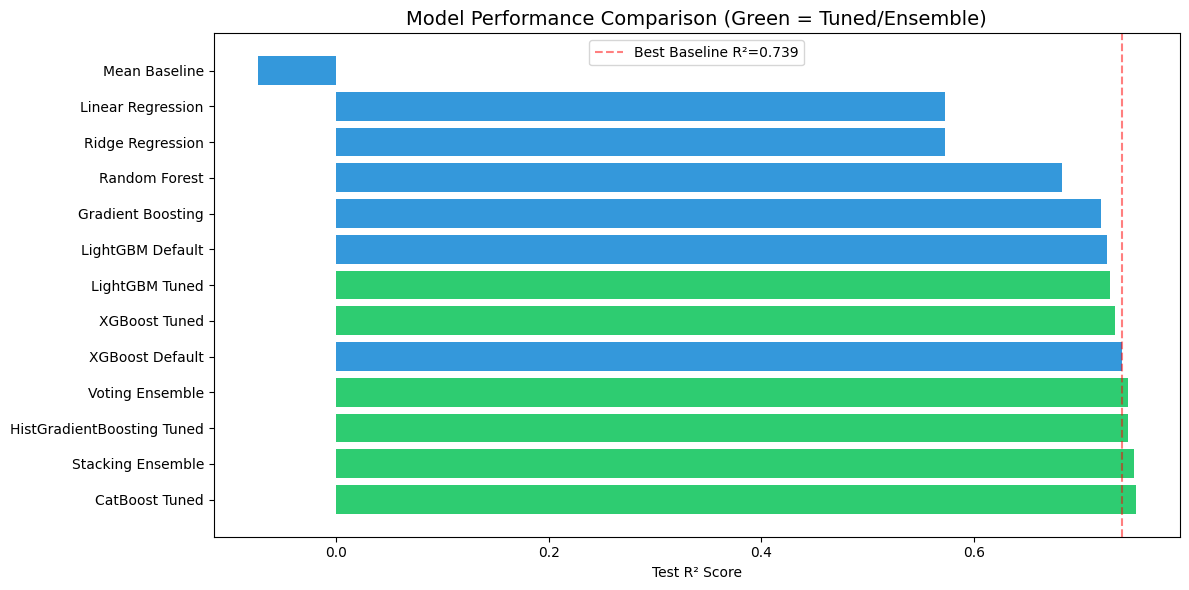

✅ Model comparison plot saved!


In [13]:
# Create comparison plot
tuned_models = [r for r in all_results if 'Tuned' in r['name'] or 'Ensemble' in r['name']]
baseline_models = [r for r in all_results if r['name'] in ['XGBoost Default', 'LightGBM Default', 'Random Forest', 'Gradient Boosting']]

fig, ax = plt.subplots(figsize=(12, 6))

# Plot all models
names = [r['name'] for r in all_results]
r2_scores = [r['test_r2'] for r in all_results]
colors = ['#2ecc71' if 'Tuned' in n or 'Ensemble' in n or 'Voting' in n else '#3498db' for n in names]

bars = ax.barh(range(len(names)), r2_scores, color=colors)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel('Test R² Score')
ax.set_title('Model Performance Comparison (Green = Tuned/Ensemble)', fontsize=14)
ax.axvline(x=baseline_best_r2, color='red', linestyle='--', alpha=0.5, label=f'Best Baseline R²={baseline_best_r2:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model comparison plot saved!")

Cell 14: Feature Importance (Best Model)

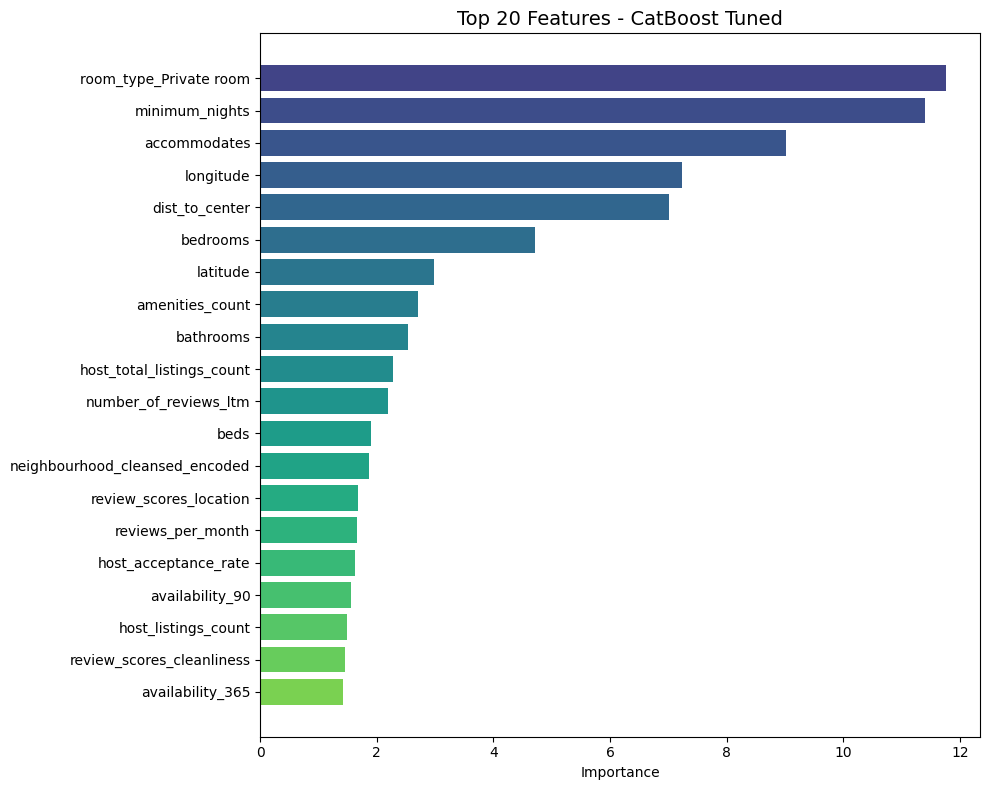


🔝 Top 10 Features (CatBoost Tuned):
   1. room_type_Private room: 11.7590
   2. minimum_nights: 11.4061
   3. accommodates: 9.0205
   4. longitude: 7.2336
   5. dist_to_center: 7.0187
   6. bedrooms: 4.7135
   7. latitude: 2.9883
   8. amenities_count: 2.7023
   9. bathrooms: 2.5376
   10. host_total_listings_count: 2.2860


In [14]:
best_model = best_overall['model']

# Get feature importance
if hasattr(best_model, 'feature_importances_'):
    importance = best_model.feature_importances_
elif hasattr(best_model, 'estimators_'):
    # For Stacking/Voting, use first estimator
    importance = best_model.estimators_[0].feature_importances_
else:
    importance = None

if importance is not None:
    feat_imp = pd.DataFrame({
        'feature': X_train.columns,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    top_20 = feat_imp.head(20)
    plt.barh(range(20), top_20['importance'].values[::-1], 
             color=plt.cm.viridis_r(np.linspace(0.2, 0.8, 20)))
    plt.yticks(range(20), top_20['feature'].values[::-1])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Features - {best_overall["name"]}', fontsize=14)
    plt.tight_layout()
    plt.savefig('feature_importance_tuned.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n🔝 Top 10 Features ({best_overall['name']}):")
    for i, (feature, imp) in enumerate(zip(feat_imp['feature'].head(10).values, 
                                             feat_imp['importance'].head(10).values)):
        print(f"   {i+1}. {feature}: {imp:.4f}")

Cell 15: Save Best Model

In [15]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

# Save best model
best_model_name = best_overall['name'].lower().replace(' ', '_')
joblib.dump(best_overall['model'], f"{models_dir}/best_model.pkl")
joblib.dump(X_train.columns.tolist(), f"{models_dir}/feature_names.pkl")

print(f"✅ Best model saved: models/best_model.pkl")
print(f"   Model: {best_overall['name']}")
print(f"   R²: {best_overall['test_r2']:.4f}")

# Also save XGBoost tuned (most reliable)
joblib.dump(best_xgb, f"{models_dir}/xgboost_tuned.pkl")
print(f"✅ XGBoost Tuned saved: models/xgboost_tuned.pkl")

# Save LightGBM tuned
joblib.dump(best_lgb, f"{models_dir}/lightgbm_tuned.pkl")
print(f"✅ LightGBM Tuned saved: models/lightgbm_tuned.pkl")

✅ Best model saved: models/best_model.pkl
   Model: CatBoost Tuned
   R²: 0.7519
✅ XGBoost Tuned saved: models/xgboost_tuned.pkl
✅ LightGBM Tuned saved: models/lightgbm_tuned.pkl


Cell 16: Final Summary

In [16]:
print("="*70)
print("🎯 HYPERPARAMETER TUNING - COMPLETE SUMMARY")
print("="*70)

print(f"\n📊 Models Trained: {len(all_results)}")
print(f"   • Baseline models: 7")
print(f"   • Tuned models: 4")
print(f"   • Ensemble models: 2")

print(f"\n🏆 Best Model: {best_overall['name']}")
print(f"   • Test R²: {best_overall['test_r2']:.4f} ({best_overall['test_r2']*100:.1f}%)")
print(f"   • Test RMSE: ${best_overall['test_rmse']:.2f}")
print(f"   • Test MAE: ${best_overall['test_mae']:.2f}")
print(f"   • Training Time: {best_overall['train_time']:.1f}s")

print(f"\n📈 Improvement Journey:")
if 'XGBoost Default' in [r['name'] for r in all_results]:
    xgb_def_r2 = [r for r in all_results if r['name'] == 'XGBoost Default'][0]['test_r2']
    print(f"   • XGBoost Default: R²={xgb_def_r2:.4f}")
print(f"   • Best Model:      R²={best_overall['test_r2']:.4f}")
print(f"   • Total Gain:      +{best_overall['test_r2'] - baseline_best_r2:.4f}")

print(f"\n📁 Files Saved:")
print(f"   ✅ models/best_model.pkl")
print(f"   ✅ models/xgboost_tuned.pkl")
print(f"   ✅ models/lightgbm_tuned.pkl")
print(f"   ✅ models/feature_names.pkl")
print(f"   ✅ model_comparison.png")
print(f"   ✅ feature_importance_tuned.png")

print(f"\n{'='*70}")
print(f"🚀 READY FOR PHASE 5: STREAMLIT APP WITH BEST MODEL!")
print(f"{'='*70}")

🎯 HYPERPARAMETER TUNING - COMPLETE SUMMARY

📊 Models Trained: 13
   • Baseline models: 7
   • Tuned models: 4
   • Ensemble models: 2

🏆 Best Model: CatBoost Tuned
   • Test R²: 0.7519 (75.2%)
   • Test RMSE: $86.67
   • Test MAE: $42.88
   • Training Time: 18.9s

📈 Improvement Journey:
   • XGBoost Default: R²=0.7385
   • Best Model:      R²=0.7519
   • Total Gain:      +0.0134

📁 Files Saved:
   ✅ models/best_model.pkl
   ✅ models/xgboost_tuned.pkl
   ✅ models/lightgbm_tuned.pkl
   ✅ models/feature_names.pkl
   ✅ model_comparison.png
   ✅ feature_importance_tuned.png

🚀 READY FOR PHASE 5: STREAMLIT APP WITH BEST MODEL!
